In [3]:
from mace.calculators import MACECalculator
from ase.build.surface import mx2
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from ase.io.espresso import read_espresso_ph
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from ase import units
from ase.io import read, Trajectory
from glob import glob

## Load Alloys test data

In [13]:
all_files = glob(f'../testing/alloys_test_data/*.ph.out')
dft_suscs = np.zeros((len(all_files),3,3))
dft_ramans = np.zeros((len(all_files),len(atoms)*3,3,3))
all_atoms = []
for i,file in enumerate(all_files):
    ph = read_espresso_ph(open(file))[1]
    atoms = ph['atoms']
    all_atoms.append(atoms)
    dft_susc = -(ph['dieltensor']-np.identity(3))*(atoms.cell.volume/(4*np.pi))
    dft_suscs[i] = dft_susc
    dft_raman = np.array(ph['raman_tensor']).reshape(len(atoms)*3,3,3)
    dft_ramans[i] = dft_raman

## Store predictions from models trained on different number of configurations
Uncomment the next cell to run and store in .pkl files 

In [20]:
# ndatas = [40, 80, 120, 160, 200, 220, 240, 280, 300, 320]
# susc_dict = {}
# raman_dict = {}

# for train_method in ['sus', 'susram']:
#     for ndata in ndatas:
        
#         if train_method == 'sus':
#             model = f'subset_models/MoWSSe_{train_method}_ndata_all_subset_{ndata}_run-123.model'
#         else:
#             model = f'subset_models/MoWSSe_{train_method}_ndata_all_subset_{ndata}_weights_10_1_run-123.model'

#         print(f"Processing model: {model}")
        
#         calc_raman = MACECalculator(
#             model_paths=model,
#             model_type="DipoleMACE",
#             device="cuda",
#             default_dtype="float64"
#         )
        
#         mace_suscs = np.zeros((len(all_atoms), 3, 3))
#         mace_ramans = np.zeros((len(all_files),len(atoms)*3,3,3))
        
#         for i, atoms in enumerate(all_atoms):
#             calc_raman.calculate(atoms)
#             mace_suscs[i] = calc_raman.results['polarizability']
            
#             mace_raman = calc_raman.results['polarizability_deriv']
#             mace_raman = -mace_raman.reshape(len(atoms),3,3,3).transpose((0, 3, 1, 2)).reshape(len(atoms)*3,3,3)
#             mace_ramans[i] = mace_raman
        
#         # Use a descriptive key for the model
#         key = f"{train_method}_ndata_{ndata}"
#         susc_dict[key] = mace_suscs
#         raman_dict[key] = mace_ramans
# # Save dictionary to .pkl file
# with open("polarizability_results.pkl", "wb") as f:
#     pickle.dump(susc_dict, f)   
# with open("raman_results.pkl", "wb") as f:
#     pickle.dump(raman_dict, f)   

Processing model: models/MoWSSe_sus_ndata_all_subset_40_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_80_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_120_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_160_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_200_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_220_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_240_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_280_run-123.model
Using head Default out of ['Default']
Processing model: models/MoWSSe_sus_ndata_all_subset_300_run-123.model
Using head Default out of ['Default']
Processing model: mod

## Plot test errors

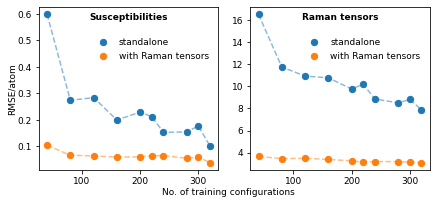

In [30]:
# Load predictions from susceptibility only models
with open("polarizability_results.pkl", "rb") as f:
    susc_results = pickle.load(f)
# Load predictions from susceptibility + Raman  models    
with open("raman_results.pkl", "rb") as f:
    raman_results = pickle.load(f)
    
ndatas = [40, 80, 120, 160, 200, 220, 240, 280, 300, 320]

fontsize = 9
plt.rcParams['font.size'] = fontsize
fig, axs = plt.subplots(1, 2, figsize=(7, 3))

label_map = {
    'sus': 'standalone',
    'susram': 'with Raman tensors'
}

for train_method in ['sus', 'susram']:
    susc_errors = []
    raman_errors = []
    
    for ndata in ndatas:
        key = f"{train_method}_ndata_{ndata}"
        mace_suscs = susc_results[key]
        mace_ramans = raman_results[key]
        
        susc_error = np.sqrt(np.mean((dft_suscs - mace_suscs)**2)) / 108
        susc_errors.append(susc_error)
        
        raman_error = np.sqrt(np.mean((dft_ramans - mace_ramans)**2))
        raman_errors.append(raman_error)
    
    # Scatter plot with optional connecting line
    axs[0].scatter(ndatas, susc_errors, label=label_map[train_method], s=40)
    axs[0].plot(ndatas, susc_errors, linestyle='--', alpha=0.5)
    
    axs[1].scatter(ndatas, raman_errors, label=label_map[train_method], s=40)
    axs[1].plot(ndatas, raman_errors, linestyle='--', alpha=0.5)

# Legend and titles
for i in range(2):
    axs[i].legend(frameon=False, bbox_to_anchor=(0.26, 0.86))

axs[0].text(0.5, 0.92, 'Susceptibilities', transform=axs[0].transAxes, ha='center', fontweight='bold')
axs[1].text(0.5, 0.92, 'Raman tensors', transform=axs[1].transAxes, ha='center', fontweight='bold')

# Axis labels
fig.text(0.5, 0.01, 'No. of training configurations', ha='center')
fig.text(0.062, 0.5, 'RMSE/atom', va='center', rotation='vertical')

plt.subplots_adjust(wspace=0.18)

plt.savefig('test_susc_raman_rmse.png', dpi=300, facecolor='white', transparent=False,
            bbox_inches='tight', pad_inches=0.02)

plt.show()


# Plot 5-fold validation errors (Using all 320 configurations)

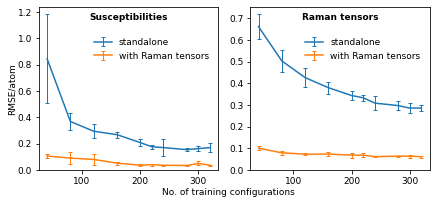

In [32]:
ndatas = [40,80,120,160,200,220,240,280,300,320]
nfold = 5

fontsize = 9
plt.rcParams['font.size'] = fontsize
fig,axs = plt.subplots(1,2,figsize=(7,3))

for train_method in ['sus','susram']:
    susc_errors = np.zeros((len(ndatas),nfold))
    raman_errors = np.zeros((len(ndatas),nfold))
    for i,ndata in enumerate(ndatas):
        
        for fold in range(nfold):

            if train_method == 'sus':
                filename = f'valid5_logs/MoWSSe_{train_method}_ndata_all_subset_{ndata}_fold{fold+1}_run-123.log'
            else:
                filename = f'valid5_logs/MoWSSe_{train_method}_ndata_all_subset_{ndata}_fold{fold+1}_run-123.log'
                
            susc_error,raman_error = read_MAE(filename,set_name='Default_Default')
            raman_error = raman_error/27
            
#             print(filename)
#             print(susc_error,raman_error)
            susc_errors[i,fold] = susc_error
            raman_errors[i,fold] = raman_error
        
    
    means_suscs = np.mean(susc_errors,axis=1)
    stds_suscs = np.std(susc_errors,axis=1)
    
    if train_method == 'sus':
        label = 'standalone'
    else:
        label = 'with Raman tensors'
    

    errorplot_susc = axs[0].errorbar(ndatas,means_suscs,yerr=stds_suscs,label=label,markersize=2,
                    elinewidth=1,capsize=2,capthick=1,barsabove=True)
    
    means_ramans = np.mean(raman_errors,axis=1)
    stds_ramans = np.std(raman_errors,axis=1)
    
    errorplot_susc = axs[1].errorbar(ndatas,means_ramans,yerr=stds_ramans,label=label,markersize=2,
                    elinewidth=1,capsize=2,capthick=1,barsabove=True)
    
axs[0].text(0.5,0.92,'Susceptibilities',transform=axs[0].transAxes,ha='center',fontweight='bold')
axs[1].text(0.5,0.92,'Raman tensors',transform=axs[1].transAxes,ha='center',fontweight='bold')
    
    
#     plt.plot(ndatas,susc_errors,label = f'MAE susceptibility ({train_method})',marker='o')
    #plt.plot(ndatas,raman_errors, label = f'MAE Raman ({train_method})',marker='o')

for i in range(len(axs)):
    axs[i].legend(frameon=False,bbox_to_anchor=(0.26,0.86))
    axs[i].set_ylim(bottom=0)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
fig.text(0.5, 0.01,'No. of training configurations', ha='center')#, fontsize=fontsize+2.5)
fig.text(0.062, 0.5,'RMSE/atom', va='center', rotation='vertical')#,fontsize=fontsize+2.5)    
    
plt.subplots_adjust(wspace=0.18)
# plt.ylabel('RMSE/atom')
# plt.xlabel('Training data')
plt.savefig('susc_raman_rmse_5fold.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)

plt.show()